# Time Series Pipeline — U.S. House Results
This notebook builds a time series of U.S. House election results interpolated 
onto the 2026 congressional district boundaries using population-weighted interpolation.

## How to use this notebook
1. Set your county parameters in the Configuration section below
2. Download the MEDSL election files (links in Issue #10) and VEST 2016/2018 shapefiles and place in data/raw/election_results/
3. Run all cells top to bottom
4. Outputs will be saved to data/processed/ with your county name in the filename

## Data sources
- Boundary files: data/raw/boundaries/ (TLC 2020, 2022, 2024 — already in repo)
- VEST boundary files: data/raw/election_results/ (tx_2016.zip, tx_2018.zip — download from VEST Harvard Dataverse https://doi.org/10.7910/DVN/NH5S2I and https://doi.org/10.7910/DVN/UBKYRU)
- Election results: MEDSL — see Issue #10 for download links
- Census blocks: data/raw/census/ (already in repo)

In [76]:
# =============================================================================
# CONFIGURATION — change these values for your county
# =============================================================================

COUNTY_FIPS = 453        # e.g. Travis = 453, Harris = 201, Tarrant = 439
COUNTY_NAME = 'TRAVIS'   # Match the name in MEDSL files (all caps)

# Output prefix for saved files
COUNTY_SLUG = COUNTY_NAME.lower().replace(' ', '_')  # e.g. 'travis', 'harris', 'tarrant'

print(f"Running pipeline for: {COUNTY_NAME} County (FIPS: {COUNTY_FIPS})")

Running pipeline for: TRAVIS County (FIPS: 453)


In [77]:
# =============================================================================
# IMPORTS
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import zipfile
import os

print("Libraries loaded")

Libraries loaded


## Step 1 — Load boundary files

We need five boundary files, one per election cycle:
- 2016 precinct boundaries: VEST 2016 shapefile (tx_2016.zip)
- 2018 precinct boundaries: VEST 2018 shapefile (tx_2018.zip)
- 2020 precinct boundaries: TLC 2020 shapefile
- 2022 precinct boundaries: TLC 2022 shapefile
- 2024 precinct boundaries: TLC 2024 shapefile

Using cycle-specific boundary files ensures population weights are calculated 
using the precinct shapes that were actually in use during each election.

All boundary files cover all Texas counties — we filter to our county using CNTY.

In [78]:
# =============================================================================
# STEP 1 — Load boundary files
# =============================================================================

# 2016 precinct boundaries — VEST shapefile
precincts_2016 = gpd.read_file('zip://../data/raw/election_results/tx_2016.zip!tx_2016.shp')
precincts_2016 = precincts_2016[precincts_2016['CNTY'] == COUNTY_FIPS].copy()
print(f"2016 precincts: {len(precincts_2016)}")

# 2018 precinct boundaries — VEST shapefile
precincts_2018 = gpd.read_file('zip://../data/raw/election_results/tx_2018.zip!tx_2018.shp')
precincts_2018 = precincts_2018[precincts_2018['CNTY'] == COUNTY_FIPS].copy()
print(f"2018 precincts: {len(precincts_2018)}")

# 2020 precinct boundaries — TLC shapefile
precincts_2020 = gpd.read_file('zip://../data/raw/boundaries/precincts20g_2020.zip!Precincts20G_2020.shp')
precincts_2020 = precincts_2020[precincts_2020['CNTY'] == COUNTY_FIPS].copy()
print(f"2020 precincts: {len(precincts_2020)}")

# 2022 precinct boundaries — TLC shapefile
precincts_2022 = gpd.read_file('zip://../data/raw/boundaries/precincts22g.zip!Precincts22G.shp')
precincts_2022 = precincts_2022[precincts_2022['CNTY'] == COUNTY_FIPS].copy()
print(f"2022 precincts: {len(precincts_2022)}")

# 2024 precinct boundaries — TLC shapefile
precincts_2024 = gpd.read_file('zip://../data/raw/boundaries/precincts24g.zip!Precincts24G.shp')
precincts_2024 = precincts_2024[precincts_2024['CNTY'] == COUNTY_FIPS].copy()
print(f"2024 precincts: {len(precincts_2024)}")

2016 precincts: 247
2018 precincts: 247
2020 precincts: 247
2022 precincts: 287
2024 precincts: 287


## Step 2 — Load 2026 congressional district boundaries

These are the target geography — the new district boundaries we want to 
translate historical results onto.

In [79]:
# =============================================================================
# STEP 2 — Load 2026 congressional district boundaries
# =============================================================================

districts = gpd.read_file('zip://../data/raw/boundaries/PLANC2333.zip!PLANC2333/PLANC2333.shp')
print(f"Total 2026 districts: {len(districts)}")
print(f"Columns: {list(districts.columns)}")

print(f"\nDistricts CRS: {districts.crs}")
print(f"Precincts CRS: {precincts_2020.crs}")

Total 2026 districts: 38
Columns: ['District', 'geometry']

Districts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",31.1666666666667],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",27.4166666666667],PARAMETER["standard_parallel_2",34.9166666666667],PARAMETER["false_easting",1000000],PARAMETER["false_northing",1000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Precincts CRS: PROJCS["NAD_1983_Lambert_Conformal_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AUTHORITY["EPSG","4

## Step 3 — Load census block population data

Census blocks are the bridge between precinct boundaries and district boundaries.
Each block has an exact population count and sits entirely within one precinct 
and one district — allowing us to calculate population-weighted splits.

We use 2020 Census blocks for all election cycles (most recent available).

In [86]:
# =============================================================================
# STEP 3 — Load census block population data
# =============================================================================

blocks = gpd.read_file('zip://../data/raw/census/Blocks.zip!Blocks.shp')
blocks = blocks[blocks['CNTY'] == str(COUNTY_FIPS).zfill(3)].copy()
print(f"Census blocks: {len(blocks)}")

# Load population counts
pop = pd.read_csv('../data/raw/census/Blocks_Pop.txt', dtype={'SCTBKEY': str})
pop = pop[pop['SCTBKEY'].str.startswith('48' + str(COUNTY_FIPS).zfill(3))].copy()
print(f"Population records: {len(pop)}")

# Join population to blocks
blocks = blocks.merge(pop[['SCTBKEY', 'total']], on='SCTBKEY', how='left')
blocks['total'] = blocks['total'].fillna(0)
print(f"Total population: {blocks['total'].sum():,.0f}")

Census blocks: 16906
Population records: 16906
Total population: 1,290,188


## Step 4 — Build weights tables

We build one weights table per election cycle using the precinct boundaries 
that were in use during that election:

- 2016 weights: uses VEST 2016 precinct boundaries
- 2018 weights: uses VEST 2018 precinct boundaries
- 2020 weights: uses TLC 2020 precinct boundaries
- 2022 weights: uses TLC 2022 precinct boundaries
- 2024 weights: uses TLC 2024 precinct boundaries

Each weights table tells us what fraction of each precinct's population
falls inside each 2026 congressional district.

Note: Precinct boundaries changed between some cycles. Using cycle-specific 
boundary files ensures accuracy. For Travis County, VEST geometry analysis 
showed <0.2% population impact from boundary changes between 2016 and 2020.

In [81]:
# =============================================================================
# STEP 4 — Build weights tables
# =============================================================================

def build_weights_table(precincts, districts, blocks, label):
    """
    Build a population-weighted interpolation table for a given set of 
    precinct boundaries intersected with 2026 congressional districts.
    
    Parameters:
        precincts: GeoDataFrame of precinct boundaries
        districts: GeoDataFrame of 2026 congressional district boundaries
        blocks: GeoDataFrame of census blocks with population counts
        label: string label for print statements (e.g. '2020')
    
    Returns:
        DataFrame with columns: old_precinct_id, new_district_id, 
                                fragment_population, weight
    """
    
    # Reproject all to same CRS
    districts_proj = districts.to_crs(precincts.crs)
    blocks_proj = blocks.to_crs(precincts.crs)
    
    # Tag each block with its precinct
    blocks_with_precinct = gpd.sjoin(
        blocks_proj,
        precincts[['PCTKEY', 'geometry']],
        how='left',
        predicate='intersects'
    )
    blocks_with_precinct = blocks_with_precinct.drop(columns=['index_right'])
    
    # Tag each block with its district
    blocks_with_both = gpd.sjoin(
        blocks_with_precinct,
        districts_proj[['District', 'geometry']],
        how='left',
        predicate='intersects'
    )
    
    # Calculate fragment populations
    fragments = blocks_with_both.groupby(
        ['PCTKEY', 'District']
    )['total'].sum().reset_index()
    fragments.columns = ['old_precinct_id', 'new_district_id', 'fragment_population']
    
    # Calculate weights
    precinct_totals = fragments.groupby('old_precinct_id')['fragment_population'].sum()
    fragments['precinct_total'] = fragments['old_precinct_id'].map(precinct_totals)
    fragments['weight'] = fragments['fragment_population'] / fragments['precinct_total']
    
    # Validate
    weight_sums = fragments.groupby('old_precinct_id')['weight'].sum()
    valid = weight_sums[weight_sums.round(6) != 1.0]
    print(f"{label} weights table: {len(fragments)} rows")
    print(f"{label} weight validation — precincts not summing to 1.0: {len(valid)}")
    
    return fragments

# Build weights tables — one per election cycle using cycle-specific boundaries
weights_2016 = build_weights_table(precincts_2016, districts, blocks, '2016')
weights_2018 = build_weights_table(precincts_2018, districts, blocks, '2018')
weights_2020 = build_weights_table(precincts_2020, districts, blocks, '2020')
weights_2022 = build_weights_table(precincts_2022, districts, blocks, '2022')
weights_2024 = build_weights_table(precincts_2024, districts, blocks, '2024')

2016 weights table: 420 rows
2016 weight validation — precincts not summing to 1.0: 2
2018 weights table: 420 rows
2018 weight validation — precincts not summing to 1.0: 2
2020 weights table: 418 rows
2020 weight validation — precincts not summing to 1.0: 2
2022 weights table: 493 rows
2022 weight validation — precincts not summing to 1.0: 0
2024 weights table: 493 rows
2024 weight validation — precincts not summing to 1.0: 0


In [82]:
# Check which precincts don't sum to 1.0 across years
for label, weights in [('2016', weights_2016), ('2018', weights_2018), ('2020', weights_2020)]:
    weight_sums = weights.groupby('old_precinct_id')['weight'].sum()
    invalid = weight_sums[weight_sums.round(6) != 1.0]
    print(f"{label} invalid precincts: {list(invalid.index)}")

2016 invalid precincts: ['4530127', '4530213']
2018 invalid precincts: ['4530127', '4530213']
2020 invalid precincts: ['4530127', '4530213']


## Step 5 — Save weights tables

In [83]:
# =============================================================================
# STEP 5 — Save weights tables
# =============================================================================
weights_2016.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2016.csv', index=False)
weights_2018.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2018.csv', index=False)
weights_2020.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2020.csv', index=False)
weights_2022.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2022.csv', index=False)
weights_2024.to_csv(f'../data/processed/{COUNTY_SLUG}_population_weights_2024.csv', index=False)
print(f"Saved {COUNTY_SLUG}_population_weights_2016.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2018.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2020.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2022.csv")
print(f"Saved {COUNTY_SLUG}_population_weights_2024.csv")

Saved travis_population_weights_2016.csv
Saved travis_population_weights_2018.csv
Saved travis_population_weights_2020.csv
Saved travis_population_weights_2022.csv
Saved travis_population_weights_2024.csv


## Step 6 — Load election results

We load U.S. House precinct-level results from MEDSL for each election cycle.
Each file covers all Texas counties — we filter to our county using county_name.

Note on 2016: the file uses different column names (state_postal, party) 
compared to later years (state_po, party_simplified). County names are also 
in title case (e.g. "Travis County") rather than uppercase ("TRAVIS").

Note on 2022/2024: MEDSL files may contain split precinct IDs with letter 
suffixes (e.g. 4530150A, 4530150B). These are precincts that straddle district 
boundaries. We strip the suffix before matching to boundary files.

Note on 2024: Some counties use a different precinct ID prefix in MEDSL 2024 
files. For Travis County, MEDSL uses 227xxxx instead of 453xxxx — we correct 
this before matching.

In [84]:
# =============================================================================
# STEP 6 — Load election results
# =============================================================================
def load_medsl(path, sep, county_name, year):
    """Load and filter MEDSL election results for a given county and year."""
    df = pd.read_csv(path, sep=sep, dtype={'precinct': str, 'county_fips': str}, 
                     low_memory=False)
    
    # Filter to county and House races
    # Always filter by state to avoid ambiguity with same county name across states
    if 'state_po' in df.columns:
        county = df[(df['county_name'] == county_name) & 
                    (df['state_po'] == 'TX')].copy()
    elif 'state_postal' in df.columns:
        county = df[(df['county_name'] == county_name) & 
                    (df['state_postal'] == 'TX')].copy()
    else:
        county = df[df['county_name'] == county_name].copy()
    
    # Filter to House races
    if 'dataverse' in county.columns:
        house = county[county['dataverse'] == 'HOUSE'].copy()
    else:
        house = county[county['office'].str.upper() == 'US HOUSE'].copy()
    
    # Construct PCTKEY
    if year == 2016:
        house['PCTKEY'] = house['precinct']
        # Strip letter suffixes from split precincts
        house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)
    elif year == 2024:
        house['PCTKEY'] = house['precinct'].str.split('_').str[0]
        # Strip letter suffixes BEFORE extracting last 4 digits
        house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)
        # Fix county-specific prefix — MEDSL uses different prefix than TLC
        house['PCTKEY'] = str(COUNTY_FIPS) + house['PCTKEY'].str[-4:].str.zfill(4)
    else:
        house['PCTKEY'] = house['precinct'].str.split('_').str[0]
        # Strip letter suffixes from split precincts
        house['PCTKEY'] = house['PCTKEY'].str.replace(r'[A-Z]$', '', regex=True)
    
    # Normalize PCTKEY — remove leading zeros to match TLC boundary format
    house['PCTKEY'] = house['PCTKEY'].str.lstrip('0')
    
    # Standardize party column
    if 'party_simplified' in house.columns:
        house = house.rename(columns={'party_simplified': 'party'})
    
    print(f"{year}: {len(house)} rows, {house['PCTKEY'].nunique()} unique precincts")
    return house

results_2016 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2016.tab', ',', COUNTY_NAME.title() + ' County', 2016)
results_2018 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2018.csv', ',', COUNTY_NAME, 2018)
results_2020 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2020.csv', ',', COUNTY_NAME, 2020)
results_2022 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2022.csv', ',', COUNTY_NAME, 2022)
results_2024 = load_medsl('../data/raw/election_results/HOUSE_precinct_general_2024.csv', ',', COUNTY_NAME, 2024)

2016: 834 rows, 247 unique precincts
2018: 741 rows, 247 unique precincts
2020: 834 rows, 247 unique precincts
2022: 906 rows, 286 unique precincts
2024: 823 rows, 287 unique precincts


In [85]:
# Check if leading zero strip would change anything for Travis
test_2018 = results_2018['PCTKEY'].copy()
stripped = test_2018.str.lstrip('0')
changed = (test_2018 != stripped).sum()
print(f"PKTKEYs that would change: {changed} of {len(test_2018)}")
print(f"Sample unchanged: {test_2018.head(3).tolist()}")

PKTKEYs that would change: 0 of 741
Sample unchanged: ['4530103', '4530103', '4530103']


## Step 7 — Run interpolation

For each election cycle we apply the appropriate weights table to the 
election results to produce interpolated vote totals by 2026 district.

- 2016: uses 2016 weights table (VEST 2016 boundaries)
- 2018: uses 2018 weights table (VEST 2018 boundaries)
- 2020: uses 2020 weights table (TLC 2020 boundaries)
- 2022: uses 2022 weights table (TLC 2022 boundaries)
- 2024: uses 2024 weights table (TLC 2024 boundaries)

In [69]:
# =============================================================================
# STEP 7 — Run interpolation
# =============================================================================

def interpolate(results, weights, year):
    """
    Apply population weights to precinct-level election results to produce
    estimated vote totals by 2026 congressional district.
    
    Parameters:
        results: DataFrame of precinct-level election results
        weights: DataFrame of population weights
        year: int election year
    
    Returns:
        DataFrame with columns: year, new_district_id, candidate, party, estimated_votes
    """
    
    # Merge results with weights
    merged = results.merge(
        weights[['old_precinct_id', 'new_district_id', 'weight']],
        left_on='PCTKEY',
        right_on='old_precinct_id',
        how='inner'
    )
    
    # Apply weights to vote counts
    merged['estimated_votes'] = merged['votes'].astype(float) * merged['weight']
    
    # Aggregate by district and candidate
    result = merged.groupby(
        ['new_district_id', 'candidate', 'party']
    )['estimated_votes'].sum().reset_index()
    
    result['year'] = year
    
    # Validation — compare total votes before and after
    original_total = results['votes'].astype(float).sum()
    interpolated_total = result['estimated_votes'].sum()
    diff = abs(original_total - interpolated_total)
    print(f"{year}: original={original_total:,.0f}, interpolated={interpolated_total:,.0f}, diff={diff:.2f}")
    
    return result

# Run interpolation for each cycle using cycle-specific weights tables
interp_2016 = interpolate(results_2016, weights_2016, 2016)
interp_2018 = interpolate(results_2018, weights_2018, 2018)
interp_2020 = interpolate(results_2020, weights_2020, 2020)
interp_2022 = interpolate(results_2022, weights_2022, 2022)
interp_2024 = interpolate(results_2024, weights_2024, 2024)

2016: original=459,722, interpolated=459,722, diff=0.00
2018: original=477,644, interpolated=477,643, diff=1.00
2020: original=593,110, interpolated=593,110, diff=0.00
2022: original=452,964, interpolated=452,964, diff=0.00
2024: original=559,719, interpolated=559,719, diff=0.00


## Step 8 — Combine into time series and save

In [38]:
# =============================================================================
# STEP 8 — Combine into time series and save
# =============================================================================

time_series = pd.concat([
    interp_2016, interp_2018, interp_2020, interp_2022, interp_2024
], ignore_index=True)

time_series = time_series[['year', 'new_district_id', 'candidate', 'party', 'estimated_votes']]
time_series['party'] = time_series['party'].str.upper()
party_map = {'DEMOCRATIC': 'DEMOCRAT', 'GREEN': 'OTHER'}
time_series['party'] = time_series['party'].replace(party_map)

output_path = f'../data/processed/{COUNTY_SLUG}_house_time_series.csv'
time_series.to_csv(output_path, index=False)

print(f"Saved: {output_path}")
print(f"\nFinal time series: {len(time_series)} rows")
print(time_series.groupby(['year', 'party'])['estimated_votes'].sum().unstack().round(0))

Saved: ../data/processed/travis_house_time_series.csv

Final time series: 355 rows
party  DEMOCRAT  LIBERTARIAN   OTHER  REPUBLICAN
year                                            
2016   279802.0      24614.0  5343.0    149963.0
2018   340345.0      12111.0     NaN    125187.0
2020   404909.0      15644.0  2411.0    170146.0
2022   324583.0       7920.0   174.0    120287.0
2024   384606.0       9340.0     NaN    165773.0


In [39]:
# Preview the time series
print(time_series.head(20).to_string())
print(f"\nSample — District 37 across all years:")
print(time_series[time_series['new_district_id'] == 37][['year', 'candidate', 'party', 'estimated_votes']].to_string())

    year  new_district_id     candidate        party  estimated_votes
0   2016               10        Cadien     DEMOCRAT      7579.658602
1   2016               10          Diaz        OTHER       407.763426
2   2016               10       Doggett     DEMOCRAT       122.913043
3   2016               10        Flores   REPUBLICAN      4179.909596
4   2016               10        Kelsey  LIBERTARIAN       867.435644
5   2016               10         Loewe  LIBERTARIAN       965.064087
6   2016               10         Matta     DEMOCRAT      8335.543221
7   2016               10        McCaul   REPUBLICAN      8107.302089
8   2016               10       Narvaiz   REPUBLICAN        16.684336
9   2016               10     Patterson  LIBERTARIAN       876.863775
10  2016               10  Schneiderman  LIBERTARIAN      2948.560020
11  2016               10         Smith  LIBERTARIAN         6.275759
12  2016               10         Smith   REPUBLICAN      7614.028773
13  2016            

## Step 9 — Visualizations

In [42]:
# =============================================================================
# STEP 9 — Visualizations
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate two-party vote share per district per year
two_party = time_series[time_series['party'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
two_party_total = two_party.groupby(['year', 'new_district_id', 'party'])['estimated_votes'].sum().reset_index()

# Pivot to get D and R side by side
pivot = two_party_total.pivot_table(
    index=['year', 'new_district_id'], 
    columns='party', 
    values='estimated_votes'
).reset_index()
pivot.columns.name = None
pivot['total'] = pivot['DEMOCRAT'] + pivot['REPUBLICAN']
pivot['dem_share'] = pivot['DEMOCRAT'] / pivot['total'] * 100
pivot['rep_share'] = pivot['REPUBLICAN'] / pivot['total'] * 100

print(pivot.to_string())

    year  new_district_id       DEMOCRAT    REPUBLICAN          total  dem_share  rep_share
0   2016               10   51339.629297  55391.808496  106731.437792  48.101694  51.898306
1   2016               11   24908.979212  21478.432547   46387.411759  53.697713  46.302287
2   2016               17     761.250662   1029.945204    1791.195866  42.499577  57.500423
3   2016               21     161.600915    218.490884     380.091799  42.516286  57.483714
4   2016               27   14781.410535   9762.497956   24543.908491  60.224355  39.775645
5   2016               31      99.717297    191.555044     291.272341  34.235072  65.764928
6   2016               37  187749.412083  61890.269869  249639.681952  75.208160  24.791840
7   2018               10   64143.936856  48365.089294  112509.026150  57.012259  42.987741
8   2018               11   31043.349398  18546.792581   49590.141979  62.599840  37.400160
9   2018               17    1043.380026    972.581377    2015.961402  51.755952

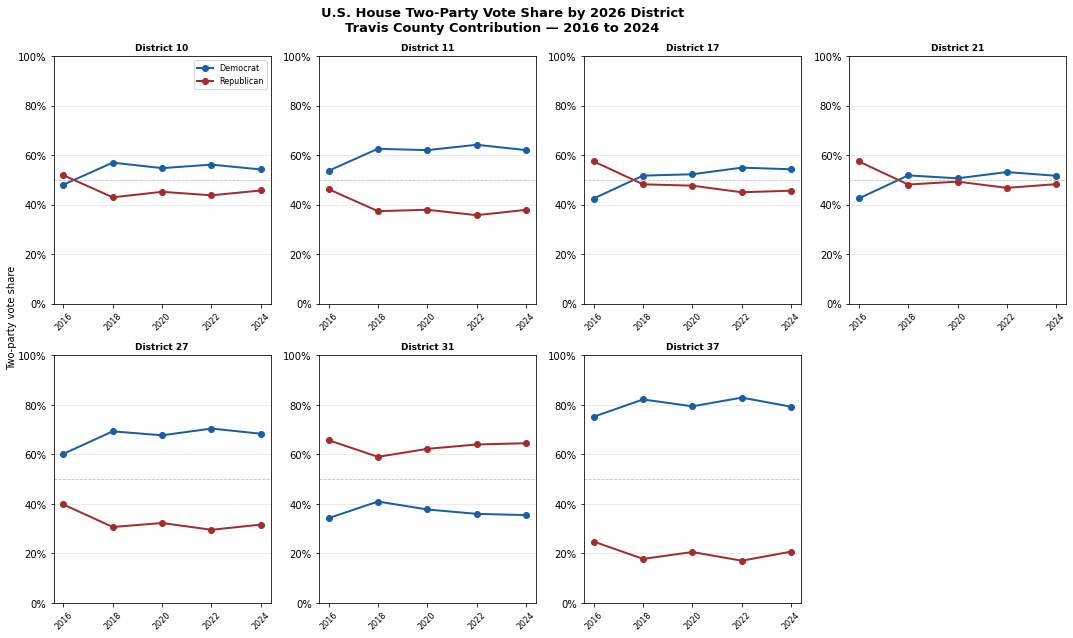

Saved figures


In [43]:
# Recalculate pivot including District 35
two_party = time_series[time_series['party'].isin(['DEMOCRAT', 'REPUBLICAN'])].copy()
two_party_total = two_party.groupby(['year', 'new_district_id', 'party'])['estimated_votes'].sum().reset_index()

pivot = two_party_total.pivot_table(
    index=['year', 'new_district_id'], 
    columns='party', 
    values='estimated_votes'
).reset_index()
pivot.columns.name = None
pivot['total'] = pivot['DEMOCRAT'] + pivot['REPUBLICAN']
pivot['dem_share'] = pivot['DEMOCRAT'] / pivot['total'] * 100
pivot['rep_share'] = pivot['REPUBLICAN'] / pivot['total'] * 100

# Separate D35 from 2026 districts
pivot_35 = pivot[pivot['new_district_id'] == 35].copy()
pivot_2026 = pivot[pivot['new_district_id'] != 35].copy()

districts_2026 = sorted(pivot_2026['new_district_id'].unique())
years = sorted(pivot['year'].unique())

# Main figure — 2026 districts (2 rows x 4 cols, last cell empty)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, district in enumerate(districts_2026):
    ax = axes[i]
    d = pivot_2026[pivot_2026['new_district_id'] == district]
    
    ax.plot(d['year'], d['dem_share'], color='#185FA5', marker='o', linewidth=2, label='Democrat')
    ax.plot(d['year'], d['rep_share'], color='#A32D2D', marker='o', linewidth=2, label='Republican')
    ax.axhline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    ax.set_title(f'District {district}', fontweight='bold', fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].axis('off')

fig.text(0.07, 0.5, 'Two-party vote share', va='center', rotation='vertical', fontsize=10)

plt.suptitle('U.S. House Two-Party Vote Share by 2026 District\nTravis County Contribution — 2016 to 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0.07, 0, 1, 1])
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_vote_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Note: District 35 existed under the 2021 congressional map (PLANC2193).
# To plot D35 history, build a separate weights table using PLANC2193 boundaries.
# This is planned for a future notebook.

print("Saved figures")

## Step 10 — Maps

Choropleth maps showing U.S. House two-party vote share by 2026 congressional 
district within Travis County — 2016 to 2024.

Data represents Travis County voter contributions only, not full district results.

In [44]:
# =============================================================================
# STEP 10 — Maps
# =============================================================================

# Load 2026 districts and clip to county boundary
county_boundary = precincts_2020.dissolve()  # Dissolve all precincts into one county boundary shape
districts_clipped = gpd.clip(districts.to_crs(precincts_2020.crs), county_boundary)
print(f"Clipped districts: {len(districts_clipped)}")
print(f"Districts: {sorted(districts_clipped['District'].unique())}")

Clipped districts: 7
Districts: [10, 11, 17, 21, 27, 31, 37]


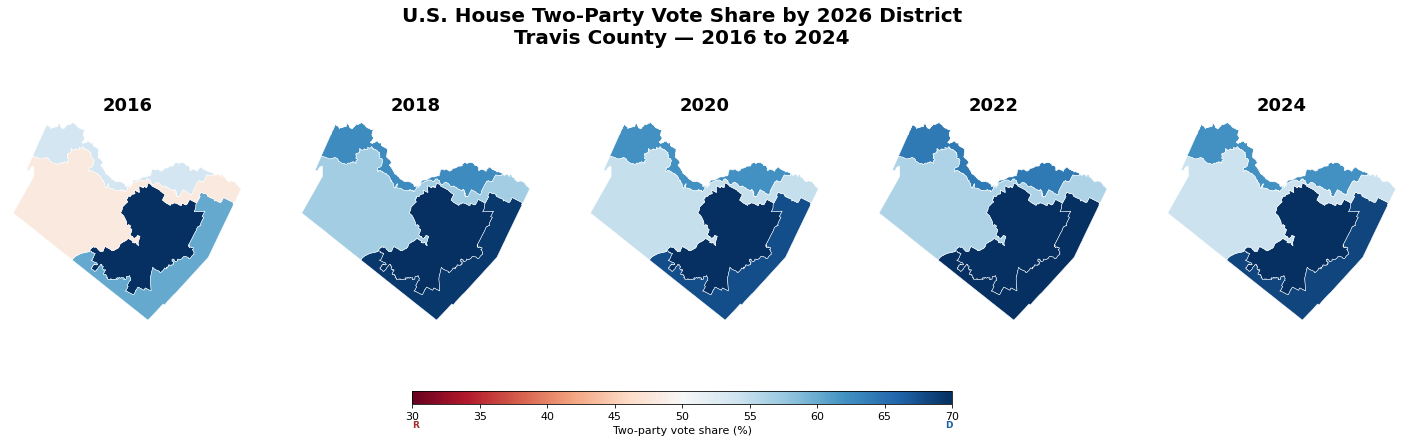

Saved map


In [46]:
years_to_plot = [2016, 2018, 2020, 2022, 2024]

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    year_data = pivot_2026[pivot_2026['year'] == year][['new_district_id', 'dem_share']].copy()
    year_data.columns = ['District', 'dem_share']
    
    districts_year = districts_clipped.merge(year_data, on='District', how='left')
    
    districts_year.plot(
        column='dem_share',
        ax=ax,
        cmap='RdBu',
        vmin=30,
        vmax=70,
        legend=False,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_title(f'{year}', fontweight='bold', fontsize=18)
    ax.set_axis_off()
    
    # Zoom into county bounds
    bounds = districts_clipped.total_bounds
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=30, vmax=70))
sm.set_array([])
cbar_ax = fig.add_axes([0.35, 0.08, 0.3, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Two-party vote share (%)', fontsize=11)
cbar.ax.text(0, -1.8, 'R', transform=cbar.ax.transAxes, fontsize=9, color='#A32D2D', fontweight='bold')
cbar.ax.text(1, -1.8, 'D', transform=cbar.ax.transAxes, fontsize=9, color='#185FA5', fontweight='bold', ha='right')

plt.suptitle(f'U.S. House Two-Party Vote Share by 2026 District\n{COUNTY_NAME.title()} County — 2016 to 2024',
             fontsize=20, fontweight='bold', y=1.0)
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved map")

In [47]:
# =============================================================================
# Change map — 2016 to 2024 shift in two-party vote share
# =============================================================================

# Get 2016 and 2024 dem share
dem_2016 = pivot_2026[pivot_2026['year'] == 2016][['new_district_id', 'dem_share']].copy()
dem_2024 = pivot_2026[pivot_2026['year'] == 2024][['new_district_id', 'dem_share']].copy()

# Calculate delta
change = dem_2016.merge(dem_2024, on='new_district_id', suffixes=('_2016', '_2024'))
change['delta'] = change['dem_share_2024'] - change['dem_share_2016']
change.columns = ['District', 'dem_2016', 'dem_2024', 'delta']
print(change[['District', 'dem_2016', 'dem_2024', 'delta']].round(1).to_string())

   District  dem_2016  dem_2024  delta
0        10      48.1      54.2    6.1
1        11      53.7      62.1    8.4
2        17      42.5      54.3   11.8
3        21      42.5      51.7    9.2
4        27      60.2      68.4    8.1
5        31      34.2      35.5    1.2
6        37      75.2      79.3    4.1


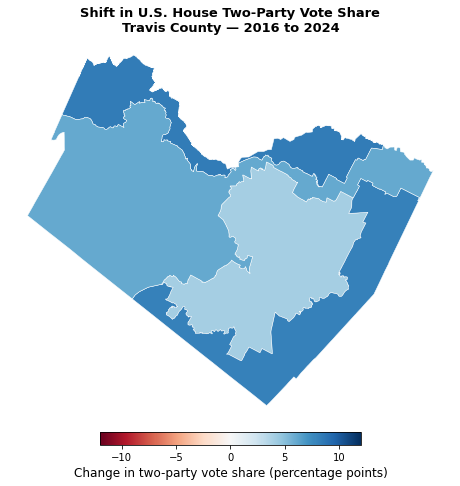

Saved change map


In [48]:
# Build change map
districts_change = districts_clipped.merge(change, on='District', how='left')
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
districts_change.plot(
    column='delta',
    ax=ax,
    cmap='RdBu',
    vmin=-12,
    vmax=12,
    legend=False,
    edgecolor='white',
    linewidth=0.5
)
ax.set_axis_off()

# Colorbar
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=plt.Normalize(vmin=-12, vmax=12))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02)
cbar.set_label('Change in two-party vote share (percentage points)', fontsize=12)

plt.title(f'Shift in U.S. House Two-Party Vote Share\n{COUNTY_NAME.title()} County — 2016 to 2024',
          fontsize=13, fontweight='bold')
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_change_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved change map")

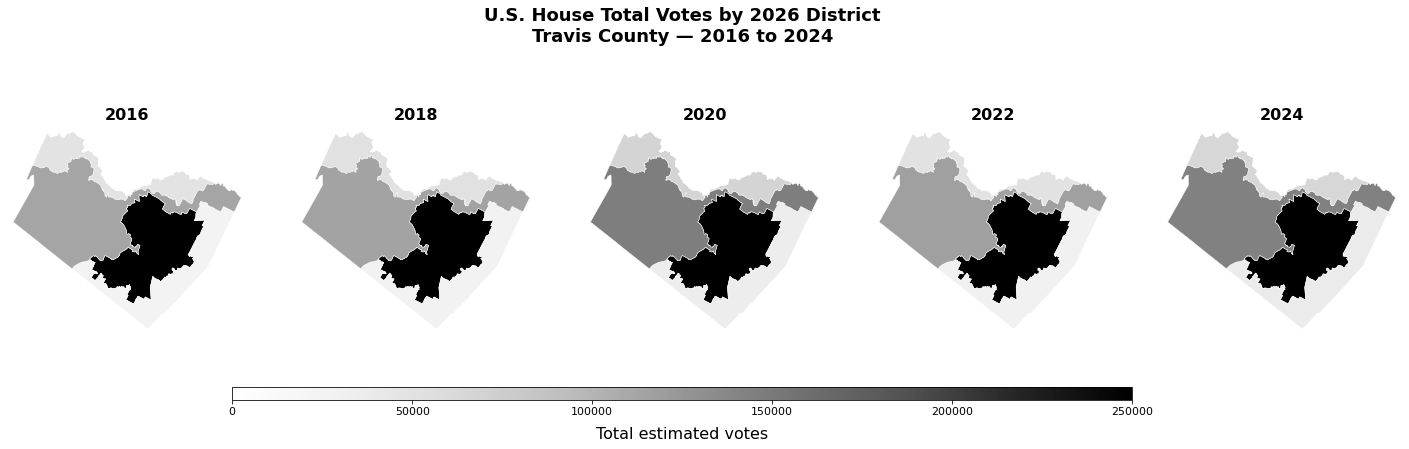

Saved turnout map


In [59]:
# =============================================================================
# Turnout map — total estimated votes per district per year
# =============================================================================
turnout = time_series.groupby(['year', 'new_district_id'])['estimated_votes'].sum().reset_index()
turnout.columns = ['year', 'District', 'total_votes']

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
for i, year in enumerate(years_to_plot):
    ax = axes[i]
    
    year_data = turnout[turnout['year'] == year][['District', 'total_votes']].copy()
    districts_year = districts_clipped.merge(year_data, on='District', how='left')
    
    districts_year.plot(
        column='total_votes',
        ax=ax,
        cmap='Greys',
        vmin=0,
        vmax=250000,
        legend=False,
        edgecolor='white',
        linewidth=0.5
    )
    
    ax.set_title(f'{year}', fontweight='bold', fontsize=16)
    ax.set_axis_off()
    
    bounds = districts_clipped.total_bounds
    ax.set_xlim(bounds[0] - 2000, bounds[2] + 2000)
    ax.set_ylim(bounds[1] - 2000, bounds[3] + 2000)

sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=0, vmax=250000))
sm.set_array([])
cbar_ax = fig.add_axes([0.25, 0.11, 0.5, 0.03])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=11)
cbar.set_label('Total estimated votes', fontsize=16, labelpad=10)

plt.suptitle(f'U.S. House Total Votes by 2026 District\n{COUNTY_NAME.title()} County — 2016 to 2024',
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig(f'../docs/images/{COUNTY_SLUG}_house_turnout_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved turnout map")

In [71]:
import pandas as pd
ts = pd.read_csv('../data/processed/travis_house_time_series.csv')
d27_2020 = ts[(ts['year'] == 2020) & (ts['new_district_id'] == 27) & (ts['party'].isin(['DEMOCRAT', 'REPUBLICAN']))]
print(d27_2020.groupby('party')['estimated_votes'].sum())

party
DEMOCRAT      23487.835539
REPUBLICAN    11201.218976
Name: estimated_votes, dtype: float64


In [72]:
d_2020 = ts[(ts['year'] == 2020) & (ts['party'].isin(['DEMOCRAT', 'REPUBLICAN']))]
totals = d_2020.groupby(['new_district_id', 'party'])['estimated_votes'].sum().unstack()
totals['total'] = totals['DEMOCRAT'] + totals['REPUBLICAN']
totals['dem_pct'] = (totals['DEMOCRAT'] / totals['total'] * 100).round(0).astype(int)
totals['rep_pct'] = (totals['REPUBLICAN'] / totals['total'] * 100).round(0).astype(int)
print(totals[['dem_pct', 'rep_pct']])

party            dem_pct  rep_pct
new_district_id                  
10                    55       45
11                    62       38
17                    52       48
21                    51       49
27                    68       32
31                    38       62
37                    79       21
